#  Combinar Dataset Final 

**Objetivo:** Combinar dataset limpio + sintéticos para crear dataset final balanceado

**Datasets a combinar:**
1. zenodo_limpio_textos.csv (4,366 clase 0 + 1,565 clase 1)
2. sinteticos_bullying.csv (2,633 clase 1)

**Dataset final esperado:**
- Clase 0: 4,366 ejemplos
- Clase 1: 4,198 ejemplos (1,565 reales + 2,633 sintéticos)
- TOTAL: 8,564 ejemplos
- Ratio: 1.04:1 (casi perfecto)

---

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Librerias importadas")

Librerias importadas


In [2]:
# Cargar datasets
df_limpio = pd.read_csv('../data/processed/zenodo_limpio_textos.csv')
df_sinteticos = pd.read_csv('../data/processed/sinteticos_bullying.csv')

print("="*70)
print("DATASETS CARGADOS")
print("="*70)

print("\n1. Dataset Zenodo limpio:")
print(f"   Total: {len(df_limpio)} ejemplos")
print(df_limpio['label'].value_counts().sort_index())

print("\n2. Dataset sinteticos:")
print(f"   Total: {len(df_sinteticos)} ejemplos")
print(df_sinteticos['label'].value_counts().sort_index())

DATASETS CARGADOS

1. Dataset Zenodo limpio:
   Total: 5931 ejemplos
label
0    4366
1    1565
Name: count, dtype: int64

2. Dataset sinteticos:
   Total: 2633 ejemplos
label
1    2633
Name: count, dtype: int64


In [3]:
# Combinar datasets
df_final = pd.concat([df_limpio, df_sinteticos], ignore_index=True)

print("="*70)
print("DATASET FINAL COMBINADO")
print("="*70)

print(f"\nTotal: {len(df_final)} ejemplos")

print("\nDistribucion por clase:")
distribucion = df_final['label'].value_counts().sort_index()
for label, count in distribucion.items():
    pct = (count / len(df_final)) * 100
    nombre = "No ofensivo" if label == 0 else "Ofensivo"
    print(f"   Clase {label} ({nombre}): {count} ({pct:.1f}%)")

ratio = max(distribucion) / min(distribucion)
print(f"\nRatio de balance: {ratio:.2f}:1")

if ratio < 1.1:
    print("   EXCELENTE balance")
elif ratio < 1.3:
    print("   MUY BUEN balance")
elif ratio < 1.5:
    print("   BUEN balance")
else:
    print("   Balance aceptable")

print("\nDistribucion por fuente:")
print(df_final['fuente'].value_counts())

DATASET FINAL COMBINADO

Total: 8564 ejemplos

Distribucion por clase:
   Clase 0 (No ofensivo): 4366 (51.0%)
   Clase 1 (Ofensivo): 4198 (49.0%)

Ratio de balance: 1.04:1
   EXCELENTE balance

Distribucion por fuente:
fuente
zenodo               5931
sintetico_chatgpt    2633
Name: count, dtype: int64


In [4]:
# Verificar duplicados entre datasets
print("="*70)
print("VERIFICACION DE DUPLICADOS")
print("="*70)

duplicados = df_final.duplicated(subset=['texto']).sum()

print(f"\nTextos duplicados: {duplicados}")

if duplicados > 0:
    print("\nEliminando duplicados...")
    antes = len(df_final)
    df_final = df_final.drop_duplicates(subset=['texto'], keep='first')
    despues = len(df_final)
    print(f"   Eliminados: {antes - despues}")
    print(f"   Total final: {despues}")
else:
    print("   No hay duplicados")

VERIFICACION DE DUPLICADOS

Textos duplicados: 107

Eliminando duplicados...
   Eliminados: 107
   Total final: 8457


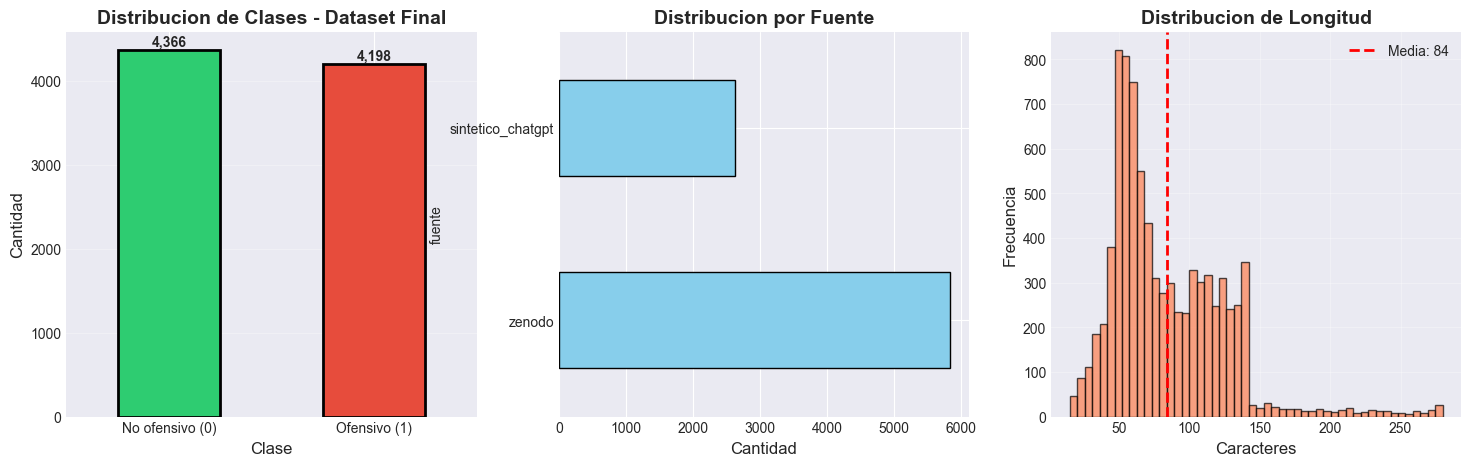

In [6]:
# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafico 1: Distribucion de clases
distribucion.plot(
    kind='bar',
    ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    linewidth=2
)
axes[0].set_title('Distribucion de Clases - Dataset Final', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].set_xticklabels(['No ofensivo (0)', 'Ofensivo (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(distribucion.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Grafico 2: Distribucion por fuente
df_final['fuente'].value_counts().plot(
    kind='barh',
    ax=axes[1],
    color='skyblue',
    edgecolor='black'
)
axes[1].set_title('Distribucion por Fuente', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Cantidad', fontsize=12)

# Grafico 3: Longitud de textos
longitudes = df_final['texto'].str.len()
axes[2].hist(longitudes, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_title('Distribucion de Longitud', fontweight='bold', fontsize=14)
axes[2].set_xlabel('Caracteres', fontsize=12)
axes[2].set_ylabel('Frecuencia', fontsize=12)
axes[2].axvline(longitudes.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {longitudes.mean():.0f}')
axes[2].legend()
axes[2].grid(alpha=0.3)


plt.show()



In [8]:
# Guardar dataset final
output_path = '../data/processed/dataset_safetalk_final.csv'
df_final.to_csv(output_path, index=False, encoding='utf-8')

print("="*70)
print("DATASET FINAL GUARDADO")
print("="*70)

print(f"\nUbicacion: {output_path}")
print(f"Total: {len(df_final)} ejemplos")

print("\nDistribucion final:")
for label, count in distribucion.items():
    pct = (count / len(df_final)) * 100
    nombre = "No ofensivo" if label == 0 else "Ofensivo"
    print(f"   Clase {label} ({nombre}): {count} ({pct:.1f}%)")

print(f"\nRatio: {ratio:.2f}:1")

print("\nEjemplos finales (10 aleatorios de cada clase):")
print("\nClase 0 (No ofensivo):")
for i, texto in enumerate(df_final[df_final['label']==0].sample(10)['texto'], 1):
    print(f"   {i}. {texto[:80]}...")

print("\nClase 1 (Ofensivo):")
for i, texto in enumerate(df_final[df_final['label']==1].sample(10)['texto'], 1):
    print(f"   {i}. {texto[:80]}...")

print("\n" + "="*70)
print("DATASET LISTO PARA ENTRENAMIENTO")
print("="*70)

print("\nProximo paso: Dividir en train/val/test (Fase 6)")

DATASET FINAL GUARDADO

Ubicacion: ../data/processed/dataset_safetalk_final.csv
Total: 8457 ejemplos

Distribucion final:
   Clase 0 (No ofensivo): 4366 (51.6%)
   Clase 1 (Ofensivo): 4198 (49.6%)

Ratio: 1.04:1

Ejemplos finales (10 aleatorios de cada clase):

Clase 0 (No ofensivo):
   1. Suenas estilo independentista. Por mí como si pierden todos los equipos, yo voy ...
   2. Lo siento, soy un poco subnormal....
   3. Hola, soy un subnormal sin personalidad ni amor propio y quiero que me cambiéis ...
   4. Si te dopas o eres supuestamente nazi... no juegas,si eres anticatalán,homófobo ...
   5. Nun entiendo que tien que ver ser de dereches pa nun ser independentista. Otru t...
   6. Una vez más, una agresión fascista sin respuesta de la justicia. Es lo que lleva...
   7. Soy del Madrid, pero vaya, que se ve que ser de un equipo u otro no influye, sig...
   8. 24h. Puigdemont celebra que queda x encima de ERC y que en el momento que pise t...
   9. Cuando eres un facha pero intelectua